In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Configuración visual
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

# El truco para Jupyter: cwd() te da la ruta de la carpeta 'notebooks'
# .parent te sube un nivel, dejándote en la raíz de tu proyecto
ROOT_DIR = Path.cwd().parent
PROCESSED_DIR = ROOT_DIR / "data/processed"

print(f"Directorio raíz detectado: {ROOT_DIR}")
print(f"Buscando datos en: {PROCESSED_DIR}")

Directorio raíz detectado: C:\Users\JPabl\PycharmProjects\ml-financial-predictor
Buscando datos en: C:\Users\JPabl\PycharmProjects\ml-financial-predictor\data\processed


In [4]:
tickers = ["AAPL", "MSFT", "GOOGL", "JPM", "SPY"]
dfs = []

for ticker in tickers:
    # Asegúrate de que los archivos .parquet existan
    path = PROCESSED_DIR / f"{ticker}.parquet"
    if path.exists():
        df_temp = pd.read_parquet(path)
        df_temp["ticker"] = ticker
        dfs.append(df_temp)
    else:
        print(f"Falta el archivo para {ticker}")

# Apilamos verticalmente y ordenamos por fecha
df = pd.concat(dfs).sort_index()

print(f"Dataset combinado: {df.shape[0]} filas, {df.shape[1]} columnas")
display(df.head(10))

Dataset combinado: 12815 filas, 34 columnas


,Open,High,Low,Close,Volume,log_return_10d,target,ret_5d,ret_10d,ret_20d,...,macd_signal,macd_diff,bb_pct,bb_width,atr_14,vol_ratio_20d,vol_change_1d,dist_52w_high,dist_52w_low,ticker
Date,,,,,,,,,,,,,,,,,,,,,
2016-01-04,23.113742,23.735456,22.976335,23.730949,270597600,-0.086089,0,-0.031330,-0.056155,-0.099568,...,-0.495253,-0.084927,0.159105,15.715934,0.513624,0.958497,0.622615,-0.198815,0.025122,AAPL
2016-01-04,37.797605,37.797605,37.070612,37.660736,67382000,-0.054609,0,0.012286,0.001827,0.000206,...,0.314141,0.045853,0.683534,5.623653,0.717395,0.834000,0.146538,-0.020089,0.565224,GOOGL
2016-01-04,48.901191,48.985303,48.182391,48.648846,25393200,-0.109701,0,-0.010546,-0.022463,-0.009496,...,0.066863,0.026376,0.495071,5.989208,0.914295,1.009262,1.037952,-0.050993,0.239170,JPM
2016-01-04,47.454844,47.874180,46.642381,47.874180,53778000,-0.080529,0,-0.006109,-0.011647,0.004879,...,0.604773,-0.054807,0.524095,4.944666,0.881023,0.774784,0.259375,-0.018921,0.410653,MSFT
2016-01-04,169.460171,169.916590,167.854226,169.908142,222353500,-0.066643,0,-0.010491,-0.014266,-0.016667,...,-0.196251,0.141739,0.426378,4.297999,2.090369,0.845131,0.814309,-0.030295,0.100815,SPY
2016-01-05,48.710013,49.038822,48.205325,48.732952,16566700,-0.138092,0,-0.039091,-0.034274,-0.027006,...,0.044023,-0.091359,0.056966,6.553135,0.989907,1.686345,0.732816,-0.079496,0.201952,JPM
2016-01-05,37.891830,38.144737,37.472793,37.764381,45216000,-0.058081,0,-0.008392,-0.013588,-0.011469,...,0.305378,-0.035053,0.269955,5.752104,0.774082,1.662005,1.057340,-0.043478,0.527864,GOOGL
2016-01-05,47.987753,48.389616,47.647044,48.092587,34079700,-0.080542,0,-0.015751,-0.016290,0.011009,...,0.574125,-0.122591,0.249622,4.639200,0.948513,1.492293,0.967433,-0.030946,0.393362,MSFT
2016-01-05,23.821048,23.843573,23.068686,23.136263,223164000,-0.059365,0,-0.025121,-0.033876,-0.089381,...,-0.515347,-0.080376,0.197818,16.067219,0.531159,1.537913,0.653522,-0.198130,0.025998,AAPL


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 12815 entries, 2016-01-04 to 2026-03-13
Data columns (total 34 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Open             12815 non-null  float64
 1   High             12815 non-null  float64
 2   Low              12815 non-null  float64
 3   Close            12815 non-null  float64
 4   Volume           12815 non-null  int64  
 5   log_return_10d   12815 non-null  float64
 6   target           12815 non-null  int64  
 7   ret_5d           12815 non-null  float64
 8   ret_10d          12815 non-null  float64
 9   ret_20d          12815 non-null  float64
 10  ret_60d          12815 non-null  float64
 11  vol_10d          12815 non-null  float64
 12  vol_20d          12815 non-null  float64
 13  vol_60d          12815 non-null  float64
 14  sma_20           12815 non-null  float64
 15  sma_50           12815 non-null  float64
 16  sma_200          12815 non-null  float64


C:\Users\JPabl\AppData\Local\Temp\ipykernel_33520\2257534007.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=target_dist.index, y=target_dist.values, palette="viridis")


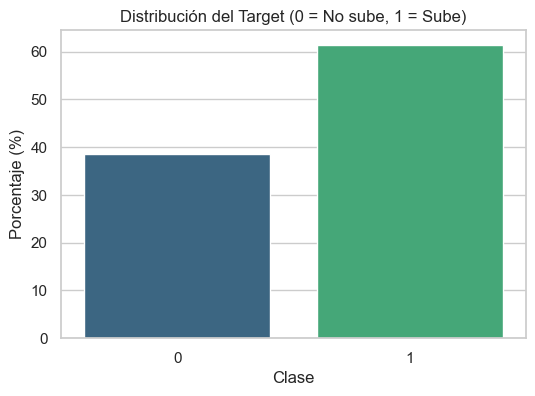


Porcentaje de casos positivos (target=1) por Ticker:


ticker
AAPL     60.749122
GOOGL    60.007803
JPM      58.330082
MSFT     61.802575
SPY      66.055404
Name: target, dtype: float64

In [5]:
# Proporción general de 1s y 0s
target_dist = df["target"].value_counts(normalize=True) * 100

plt.figure(figsize=(6, 4))
sns.barplot(x=target_dist.index, y=target_dist.values, palette="viridis")
plt.title("Distribución del Target (0 = No sube, 1 = Sube)")
plt.ylabel("Porcentaje (%)")
plt.xlabel("Clase")
plt.show()

# Distribución por Ticker
print("\nPorcentaje de casos positivos (target=1) por Ticker:")
display(df.groupby("ticker")["target"].mean() * 100)

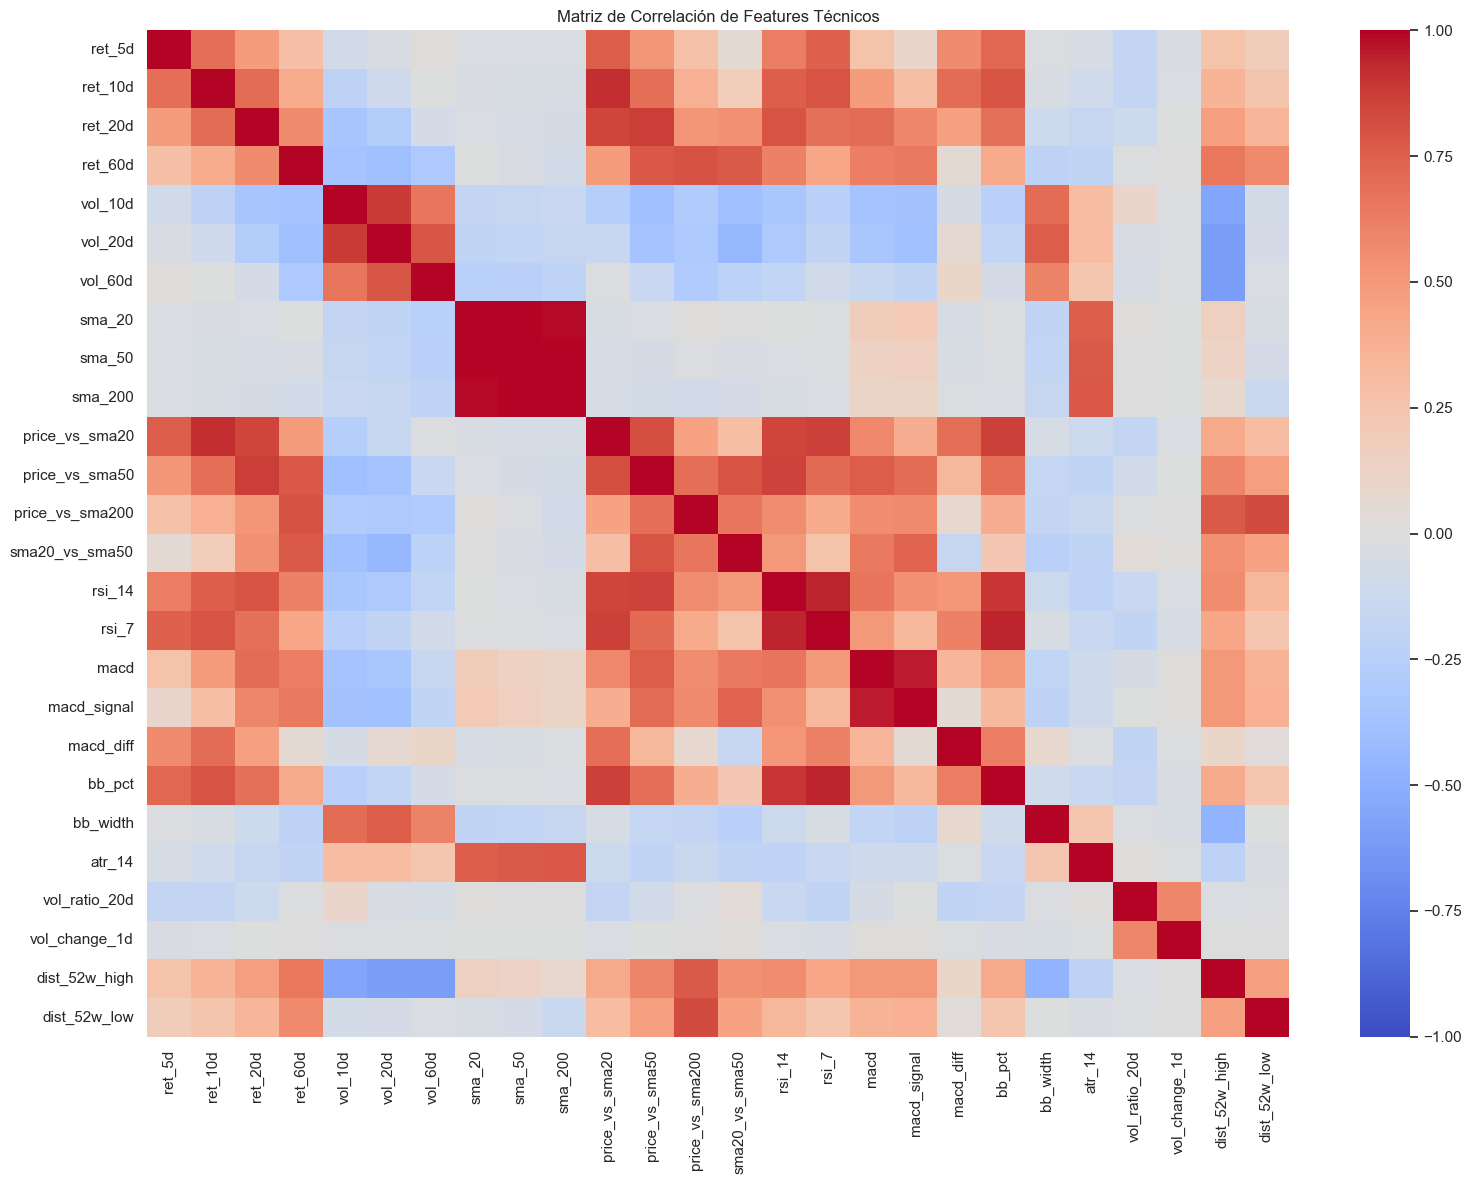

In [6]:
# Seleccionamos solo las variables numéricas, excluyendo el precio de cierre y target
cols_to_exclude = ["Open", "High", "Low", "Close", "Volume", "target", "log_return_10d"]
features = [c for c in df.columns if c not in cols_to_exclude and c != "ticker"]

# Matriz de correlación
corr_matrix = df[features].corr()

plt.figure(figsize=(16, 12))
# Usamos un mapa de calor divergente (rojo para correlación negativa, azul para positiva)
sns.heatmap(corr_matrix, cmap="coolwarm", center=0, annot=False, vmin=-1, vmax=1)
plt.title("Matriz de Correlación de Features Técnicos")
plt.tight_layout()
plt.show()

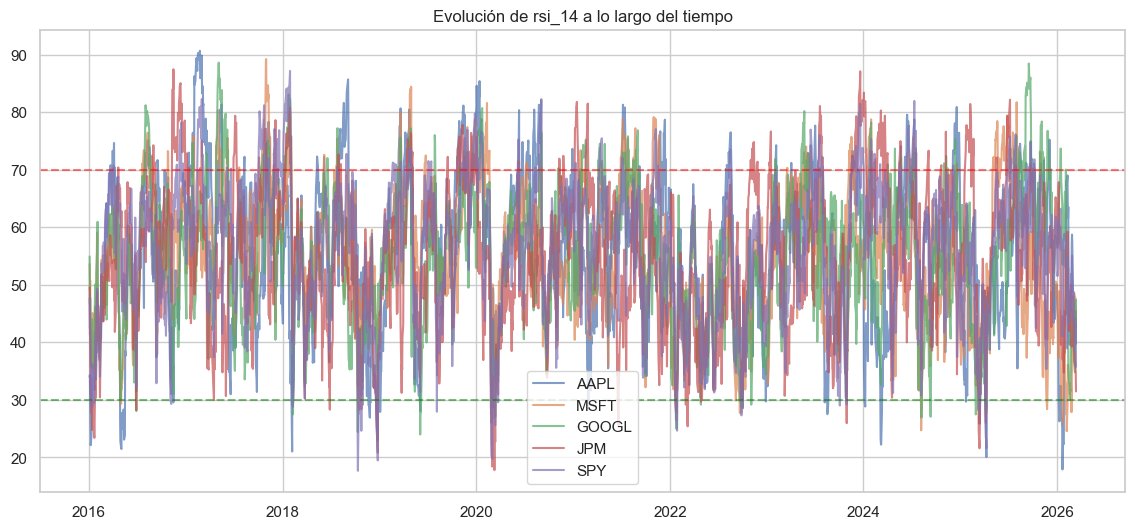

In [7]:
# Elegimos una variable para graficar, ej. el RSI de 14 días
feature_to_plot = "rsi_14"

plt.figure(figsize=(14, 6))
for ticker in tickers:
    # Filtramos por ticker
    data_ticker = df[df["ticker"] == ticker]
    # Graficamos el feature a lo largo del índice de tiempo
    plt.plot(data_ticker.index, data_ticker[feature_to_plot], label=ticker, alpha=0.7)

# Líneas de referencia típicas para el RSI (30 sobreventa, 70 sobrecompra)
plt.axhline(70, color='red', linestyle='--', alpha=0.5)
plt.axhline(30, color='green', linestyle='--', alpha=0.5)

plt.title(f"Evolución de {feature_to_plot} a lo largo del tiempo")
plt.legend()
plt.show()

In [8]:
import numpy as np

# 1. Crear una máscara para aislar solo el triángulo superior de la matriz
# (El k=1 excluye la diagonal perfecta de 1.0)
upper_triangle_mask = np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)

# 2. Aplicar la máscara a la matriz de correlación
upper_corr = corr_matrix.where(upper_triangle_mask)

# 3. "Aplanar" la matriz para convertirla en una lista de pares (Serie de Pandas)
corr_pairs = upper_corr.unstack().dropna()

# 4. Ordenar los pares por su valor absoluto (para que los -0.9 y +0.9 queden hasta arriba)
top_correlated = corr_pairs.loc[corr_pairs.abs().sort_values(ascending=False).index]

# Mostrar el Top 20 de variables más correlacionadas
print("Top 20 pares de variables más correlacionadas:")
print("-" * 50)
print(top_correlated.head(20))

Top 20 pares de variables más correlacionadas:
--------------------------------------------------
sma_50           sma_20             0.998847
sma_200          sma_50             0.994138
                 sma_20             0.991227
macd_signal      macd               0.953440
bb_pct           rsi_7              0.942513
rsi_7            rsi_14             0.937548
price_vs_sma20   ret_10d            0.915761
bb_pct           rsi_14             0.890958
vol_20d          vol_10d            0.881799
price_vs_sma50   ret_20d            0.869360
bb_pct           price_vs_sma20     0.863147
rsi_7            price_vs_sma20     0.860576
rsi_14           price_vs_sma50     0.852195
                 price_vs_sma20     0.849777
price_vs_sma20   ret_20d            0.847311
dist_52w_low     price_vs_sma200    0.824979
price_vs_sma50   price_vs_sma20     0.813107
price_vs_sma200  ret_60d            0.803395
bb_pct           ret_10d            0.794509
sma20_vs_sma50   price_vs_sma50     0.793607
dt

Proporción de desbalance (scale_pos_weight calculada): 0.6288
Entrenando XGBoost...


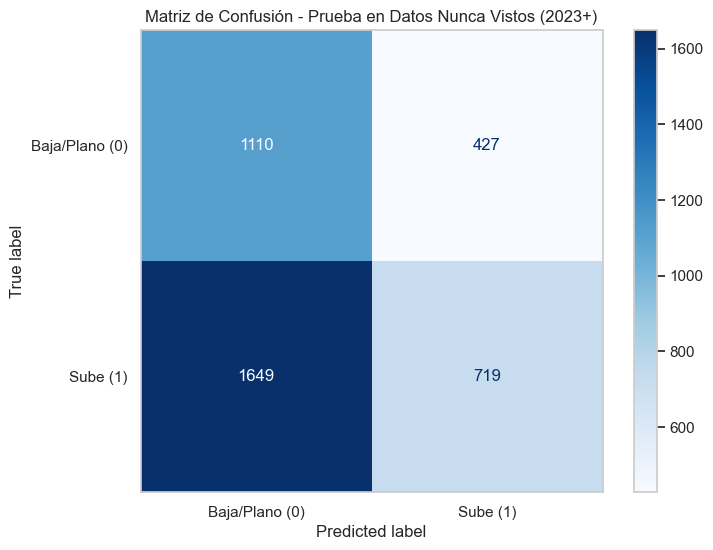


Reporte de Clasificación:
-----------------------------------------------------------------
                precision    recall  f1-score   support

Baja/Plano (0)       0.40      0.72      0.52      1537
      Sube (1)       0.63      0.30      0.41      2368

      accuracy                           0.47      3905
     macro avg       0.51      0.51      0.46      3905
  weighted avg       0.54      0.47      0.45      3905



In [9]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import xgboost as xgb
import matplotlib.pyplot as plt

# 1. Separar variables (Features) y la etiqueta (Target)
cols_to_exclude = ["Open", "High", "Low", "Close", "Volume", "target", "log_return_10d", "ticker"]
features = [c for c in df.columns if c not in cols_to_exclude]

X = df[features]
y = df["target"]

# 2. Split temporal rápido (Simulando la purga de forma sencilla para el EDA)
# Entrenamos con todo hasta el 2022 y probamos con 2023 en adelante
train_mask = df.index <= "2022-12-31"
test_mask = df.index > "2023-01-31" # Dejamos enero como "zona muerta" (embargo)

X_train, y_train = X[train_mask], y[train_mask]
X_test, y_test = X[test_mask], y[test_mask]

# 3. Calcular el factor de desbalance exacto de Train
scale = (y_train == 0).sum() / (y_train == 1).sum()
print(f"Proporción de desbalance (scale_pos_weight calculada): {scale:.4f}")

# 4. Entrenar el clasificador
print("Entrenando XGBoost...")
model_xgb = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=3,
    learning_rate=0.05,
    scale_pos_weight=scale, # <-- Aquí forzamos al modelo a no ignorar los 0s
    random_state=42,
    verbosity=0
)
model_xgb.fit(X_train, y_train)

# 5. Predecir el futuro (Test)
y_pred = model_xgb.predict(X_test)

# 6. Graficar la Matriz de Confusión
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Baja/Plano (0)", "Sube (1)"])

plt.figure(figsize=(8, 6))
disp.plot(cmap="Blues", values_format="d", ax=plt.gca())
plt.title("Matriz de Confusión - Prueba en Datos Nunca Vistos (2023+)")
plt.grid(False) # Apagamos la cuadrícula de fondo de Seaborn para que se vea limpio
plt.show()

# 7. Imprimir el escáner a profundidad
print("\nReporte de Clasificación:")
print("-" * 65)
print(classification_report(y_test, y_pred, target_names=["Baja/Plano (0)", "Sube (1)"]))